In [25]:
import pandas as pd 

In [26]:
import numpy as np 

# Data Lookup  

In [27]:
df = pd.read_csv('./Data/train.csv')

In [28]:
df.shape

(2000, 21)

In [29]:
df.head ()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [30]:
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [31]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

# SPlitting Data 

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
# SPLIT X AND Y 

X = df.drop('price_range', axis=1).values
y = df['price_range'].values

In [34]:
X_train ,X_test, y_train   , y_test = train_test_split(
    X , y , test_size=0.2, random_state=42 , stratify=y
)

In [35]:
# Scaling Data
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()

In [36]:
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

# Training Neuron Network 

In [37]:
import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.optim.lr_scheduler as StepLR

In [38]:
# Converting Numpy Matrix toPytorch tensors 
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.long)
X_test_tensors = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensors = torch.tensor(y_test,dtype=torch.long)

In [39]:
# Default Class for Neuron network 

class  MobilePriceNet(nn.Module):
    def __init__(self,input_dim=20,num_classes=4):
        super(MobilePriceNet,self).__init__()
        self.layer1 = nn.Linear(input_dim,64)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(64,32)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(32,16)
        self.relu3 = nn.ReLU()
        self.output = nn.Linear(16,num_classes)

    def forward(self,x):
        x  = self.relu1(self.layer1(x))
        x  = self.relu2(self.layer2(x))
        x  = self.relu3(self.layer3(x))
        x  = self.output(x)

        return x

In [40]:
model = MobilePriceNet(input_dim=X_train.shape[1], num_classes=4)

In [41]:
# ERROR Calc + Adam + StepLrScheduler  

criteria = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters() , lr=0.01)



In [43]:
# Drop learning rate by 50% every 30 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Training Epochs

In [44]:
epochs = 100
train_Losses= []

In [46]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad() # Clear old gradients

    # Forward Pass
    outputs = model(X_train_tensor)
    loss = criteria(outputs,y_train_tensor)

    # Backward Pass 
    loss.backward()
    optimizer.step()

    # Step  the scheduler 
    scheduler.step()

    train_Losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')

Epoch [10/100], Loss: 0.9684, LR: 0.010000
Epoch [20/100], Loss: 0.1800, LR: 0.010000
Epoch [30/100], Loss: 0.0255, LR: 0.005000
Epoch [40/100], Loss: 0.0076, LR: 0.005000
Epoch [50/100], Loss: 0.0036, LR: 0.005000
Epoch [60/100], Loss: 0.0022, LR: 0.002500
Epoch [70/100], Loss: 0.0018, LR: 0.002500
Epoch [80/100], Loss: 0.0016, LR: 0.002500
Epoch [90/100], Loss: 0.0015, LR: 0.001250
Epoch [100/100], Loss: 0.0014, LR: 0.001250


# Evaluating The model 

In [47]:
from sklearn.metrics import accuracy_score, classification_report

In [51]:
model.eval()
with torch.no_grad(): # Turn off gradient tracking for testing
    test_outputs = model(X_test_tensors)
    # Get the index of the max log-probability (the predicted class)
    _, predicted = torch.max(test_outputs, 1)
    
    acc = accuracy_score(y_test_tensors.numpy(), predicted.numpy())
    print(f"\nFinal Test Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_tensors.numpy(), predicted.numpy()))


Final Test Accuracy: 0.9125

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       100
           1       0.89      0.87      0.88       100
           2       0.90      0.89      0.89       100
           3       0.94      0.95      0.95       100

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



# Plot The  Error Graph 

In [53]:
import matplotlib.pyplot as plt

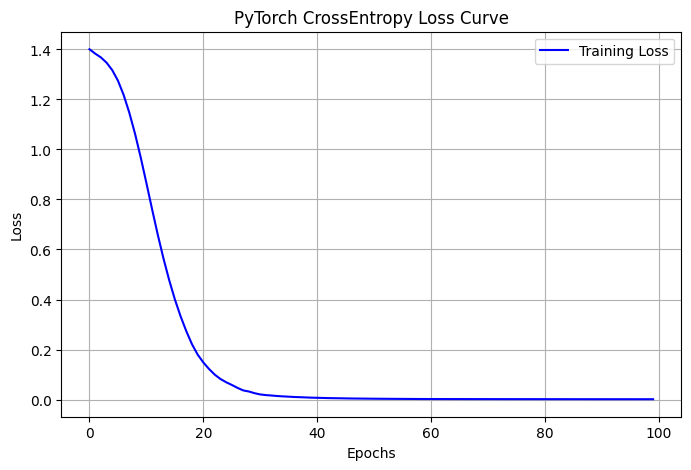

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(train_Losses, label='Training Loss', color='blue')
plt.title('PyTorch CrossEntropy Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()